In [10]:
from scMM.file._anndata import MetaboData
import pandas as pd
import numpy as np

df = pd.read_csv("/home/zby/scMM/data/ethology_new/Compound_measurements.csv")
sample_mask = df.columns.to_series().str.match(r"^WORM-\d{8}$")
IS_MASK = df["IS"].values == "x"
IS_inten = df.loc[IS_MASK, :]
df = df.loc[IS_MASK == False, :]
high_mean = df["Highest Mean"].values
low_mean = df["Lowest Mean"].values
FC = df["Max Fold Change"].values
data = MetaboData(
    X = df.loc[:, sample_mask].values.T,
    obs = pd.DataFrame({
        "name": df.columns[sample_mask].values
    }),
    var = pd.DataFrame({
        "mz": df["m/z"].values,
        "rt": df["Retention time (min)"].values,
        "isotope": df["Isotope Distribution"].values,
        "snr": [FC[i] if high_mean[i] == "Condition 1" else 1/FC[i] for i in range(len(FC))],
        "identification": df["Accepted Description"].values
    }),
    is_inten = IS_inten.loc[:, sample_mask].T
)
is_mz_obs = IS_inten["m/z"].values

/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


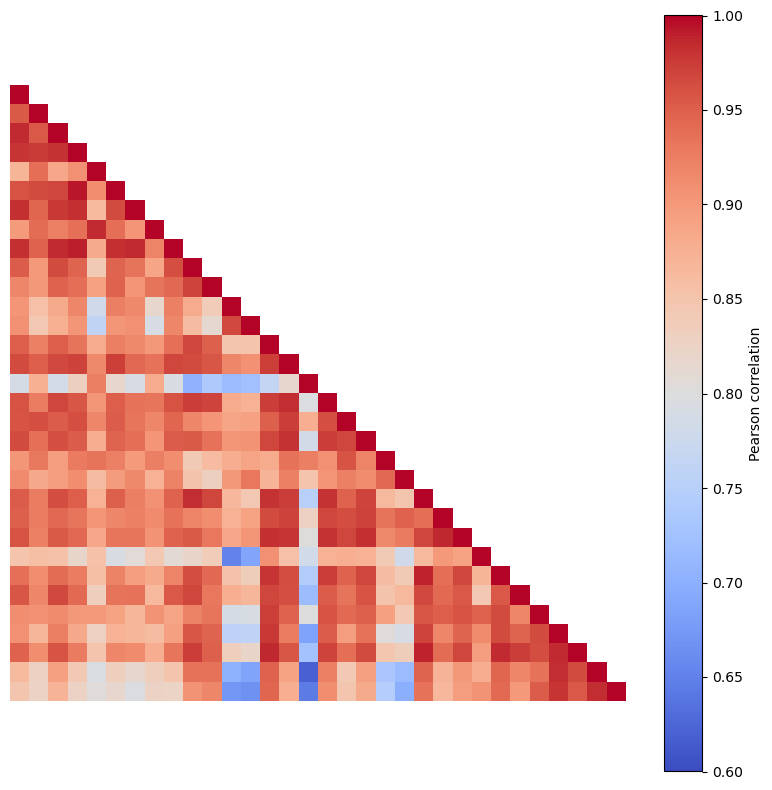

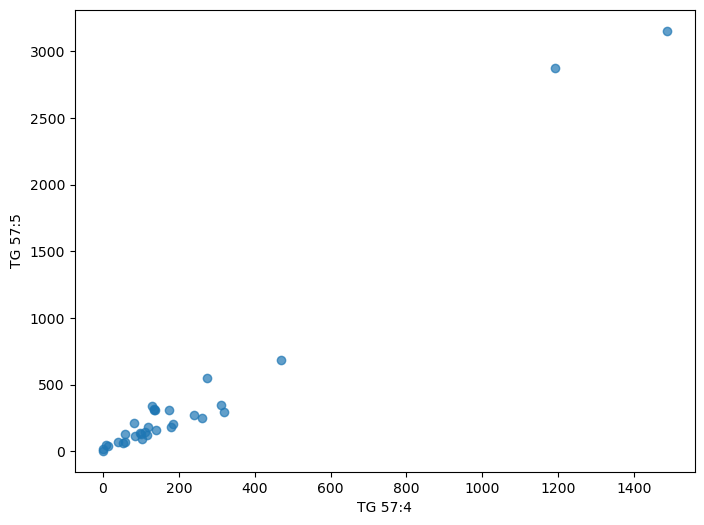

In [4]:
data.metabolite_correlation_heatmap(mode = "sample", triangle = "lower", show_ticks = False, colorbar = True, vmax = 1.0, vmin = 0.6, save_path="/home/zby/scMM/data/ethology_new/sample_correlation_heatmap_elo-1.svg")
data.feature_scatter("identification", "TG 57:4", "TG 57:5", save_path="/home/zby/scMM/data/ethology_new/feature_scatter_elo-1.svg")

INFO:root:Using 12 out of 37 IS for calibration (CV < 0.3)


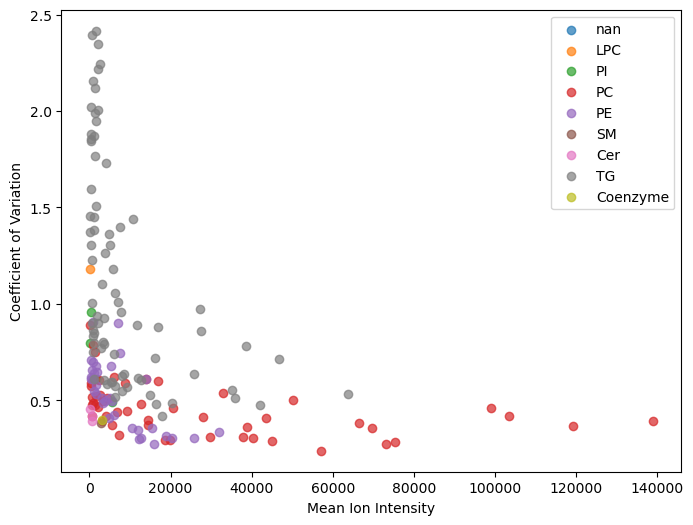

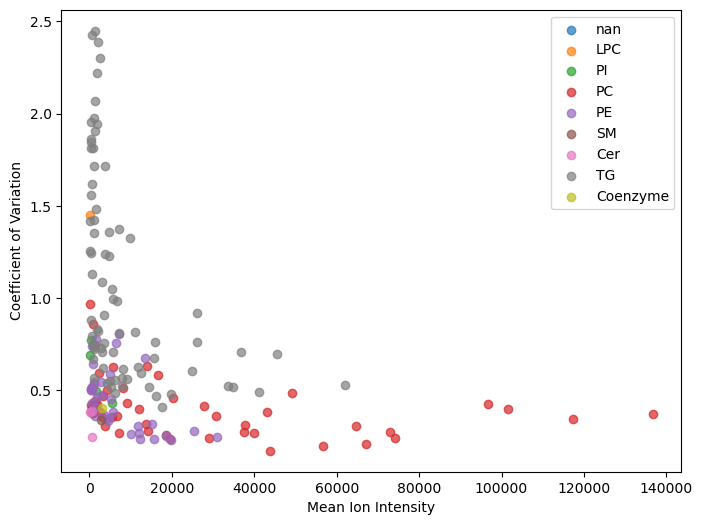

In [5]:
import logging
logging.basicConfig(level=logging.INFO)

data.var["label"] = data.var["identification"].str.extract(r"^([A-Za-z]+)")[0]
data.plot_features(color_key = "label", save_path="/home/zby/scMM/data/ethology_new/feature_plot_WT_30_uncalib.svg")
data.gmis_calibration(n_pc = 3, shrinkage = 0.7, is_cv_threshold=0.3)
data.plot_features(color_key = "label", save_path="/home/zby/scMM/data/ethology_new/feature_plot_WT_30_calib.svg")

array([[1.        ,        nan,        nan, ...,        nan,        nan,
               nan],
       [0.9466403 , 1.        ,        nan, ...,        nan,        nan,
               nan],
       [0.98463001, 0.94299327, 1.        , ...,        nan,        nan,
               nan],
       ...,
       [0.95102945, 0.89817908, 0.96923814, ..., 1.        ,        nan,
               nan],
       [0.82823247, 0.77354405, 0.86482095, ..., 0.94268383, 1.        ,
               nan],
       [0.85208136, 0.81541665, 0.8822653 , ..., 0.9572997 , 0.98361857,
        1.        ]], shape=(32, 32))

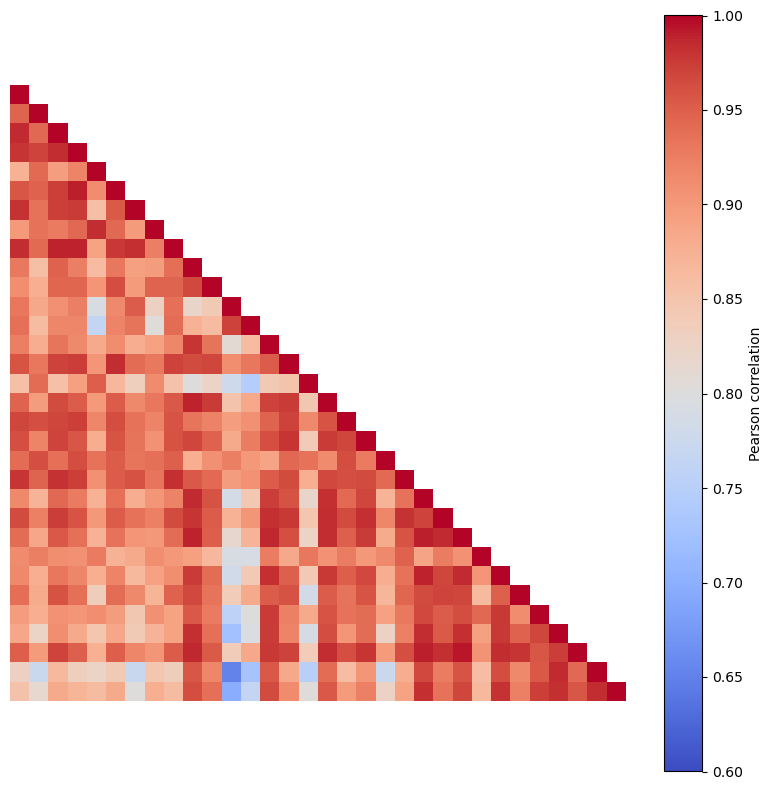

In [6]:
data.metabolite_correlation_heatmap(mode = "sample", triangle = "lower", show_ticks = False, colorbar = True, vmax = 1.0, vmin = 0.6, save_path="/home/zby/scMM/data/ethology_new/metabolite_correlation_heatmap_WT_30_calib.svg")

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
def draw_pca(data:MetaboData, title, process_X = lambda x: x):
    pca = PCA(n_components=2)
    decomp = pca.fit_transform(process_X(data.X))
    for i, name in enumerate(data.obs["name"].values):
        plt.text(decomp[i, 0], decomp[i, 1], name, fontsize = 5)
    plt.scatter(decomp[:, 0], decomp[:, 1])
    plt.title(title)
    plt.show()

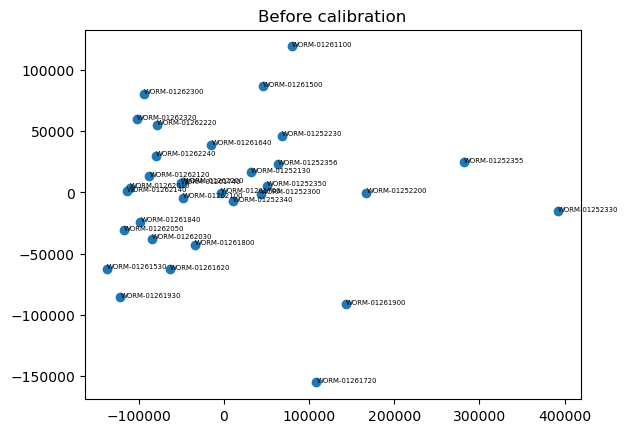

INFO:root:Using 1 out of 37 IS for calibration (CV < 0.25)


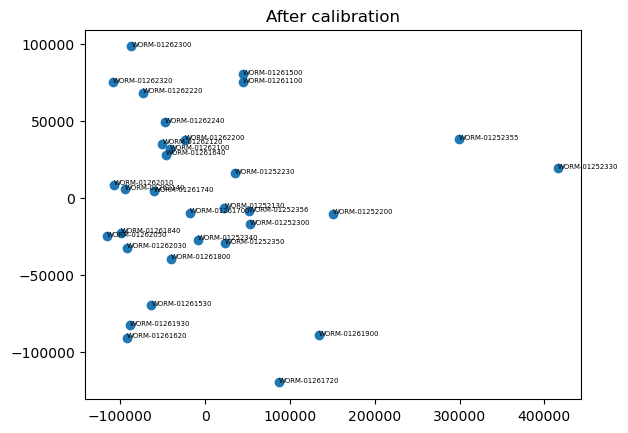

In [12]:
draw_pca(data, "Before calibration")
data.gmis_calibration(n_pc = 3, shrinkage = 0.7, is_cv_threshold=0.25)
draw_pca(data, "After calibration")

In [13]:
is_mz_obs.sort()
is_mz_true = [543.5477,571.579,575.5406,599.6103,603.5719,627.6416,631.6032,655.6032,655.6729,681.5226,681.6188,
709.5539,710.6157,723.5695,731.692,737.5852,738.647,751.6008,757.7076,766.6783,779.6321,785.7389,794.7096,
803.6321,813.7702,817.5597,822.7409,829.6478,841.8015,845.591,867.8172,873.6223,893.8328,897.6223,
919.8485,923.638,947.8798]
print(len(is_mz_true))
print(len(is_mz_obs))
data.mz_calibration(mz_is_true = is_mz_true, mz_is_obs = is_mz_obs)
print(data.var["mz_calibrated"].values)

37
37
[508.34012309 480.308394   522.3552313  468.30903353 496.34093822
 798.50675501 750.50695987 738.5068482  800.52218345 776.52241923
 764.52277446 826.53818631 740.52237974 790.53841943 802.53830859
 732.59734783 716.52280332 728.52257248 752.5226467  724.4912864
 766.5386026  778.53818837 828.55331526 700.49173328 704.52246726
 712.49113814 742.53844618 754.53768095 804.55351243 900.55958186
 664.4909638  688.49197191 706.5381433  718.53850796 730.53920881
 883.53246679 676.49138266 726.50742284 750.50720796 792.55402436
 830.5688524  888.56030809 768.55328505 780.55359091 702.50697312
 714.50680928 738.5070959  744.55361512 756.55354748 764.52269266
 806.56913737 732.55370606 690.50667496 728.52237108 740.52193665
 752.52240111 782.56881175 794.56858501 770.56882819 746.56881207
 808.58376792 716.52241012 734.56723552 758.56941782 784.58465959
 902.5752909  754.53707525 704.52256256 820.58492477 742.53803048
 766.5381783  834.59841879 730.53829672 756.55349508 772.58484222
 760.

In [14]:
eth_df = pd.read_csv("/home/zby/scMM/data/ethology_new/edited/features_summary_tierpsy_trajectory_manual_20260129_132814.csv", index_col=0)
del_mask = eth_df.isna().all(axis = 0)
eth_df = eth_df.loc[:, ~del_mask].astype(np.float64)

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
Y_imputed = imputer.fit_transform(eth_df.values)
eth_df = pd.DataFrame(Y_imputed, index=eth_df.index, columns=eth_df.columns)

data.add_omics("ethology", eth_df)
Wx, Wy, Zx, Zy = data.max_cov_subspace("ethology", lam_x=2.5, lam_y = 7.0)

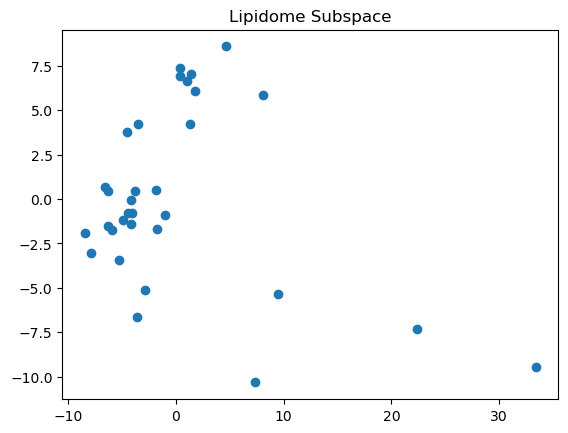

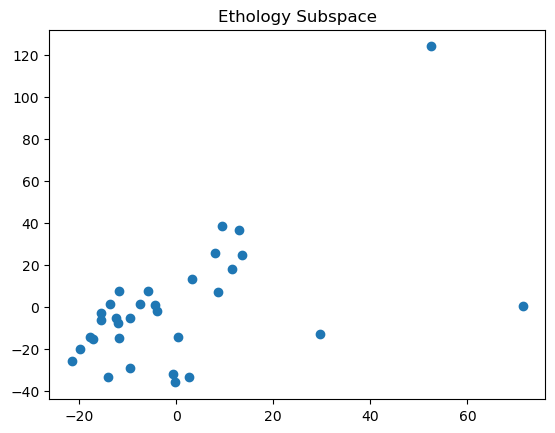

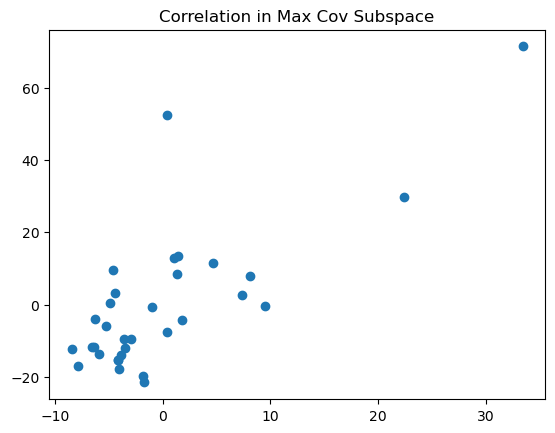

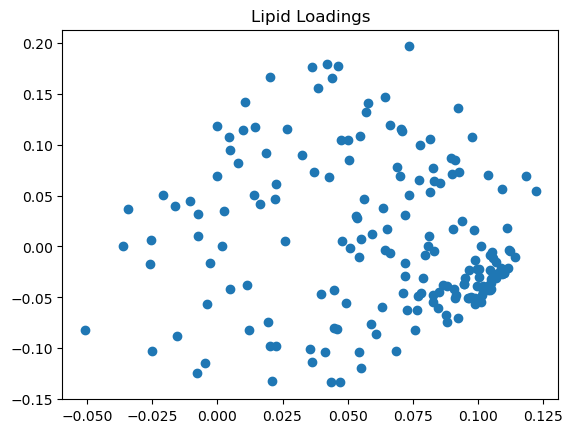

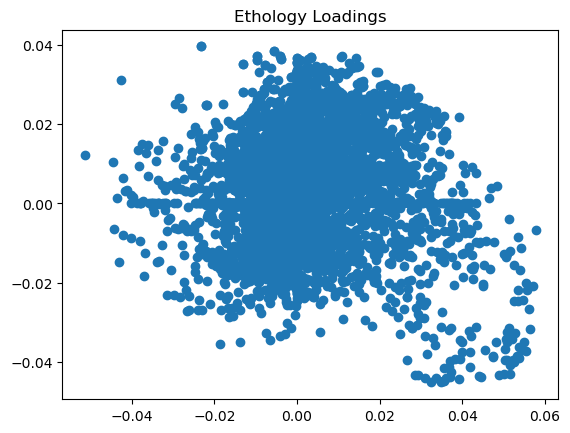

In [15]:
plt.scatter(Zx[:, 0], Zx[:, 1])
plt.title("Lipidome Subspace")
plt.show()
plt.scatter(Zy[:, 0], Zy[:, 1])
plt.title("Ethology Subspace")
plt.show()
plt.scatter(Zx[:, 0], Zy[:, 0])
plt.title("Correlation in Max Cov Subspace")
plt.show()
plt.scatter(Wx[:, 0], Wx[:, 1])
plt.title("Lipid Loadings")
plt.show()
plt.scatter(Wy[:, 0], Wy[:, 1])
plt.title("Ethology Loadings")
plt.show()

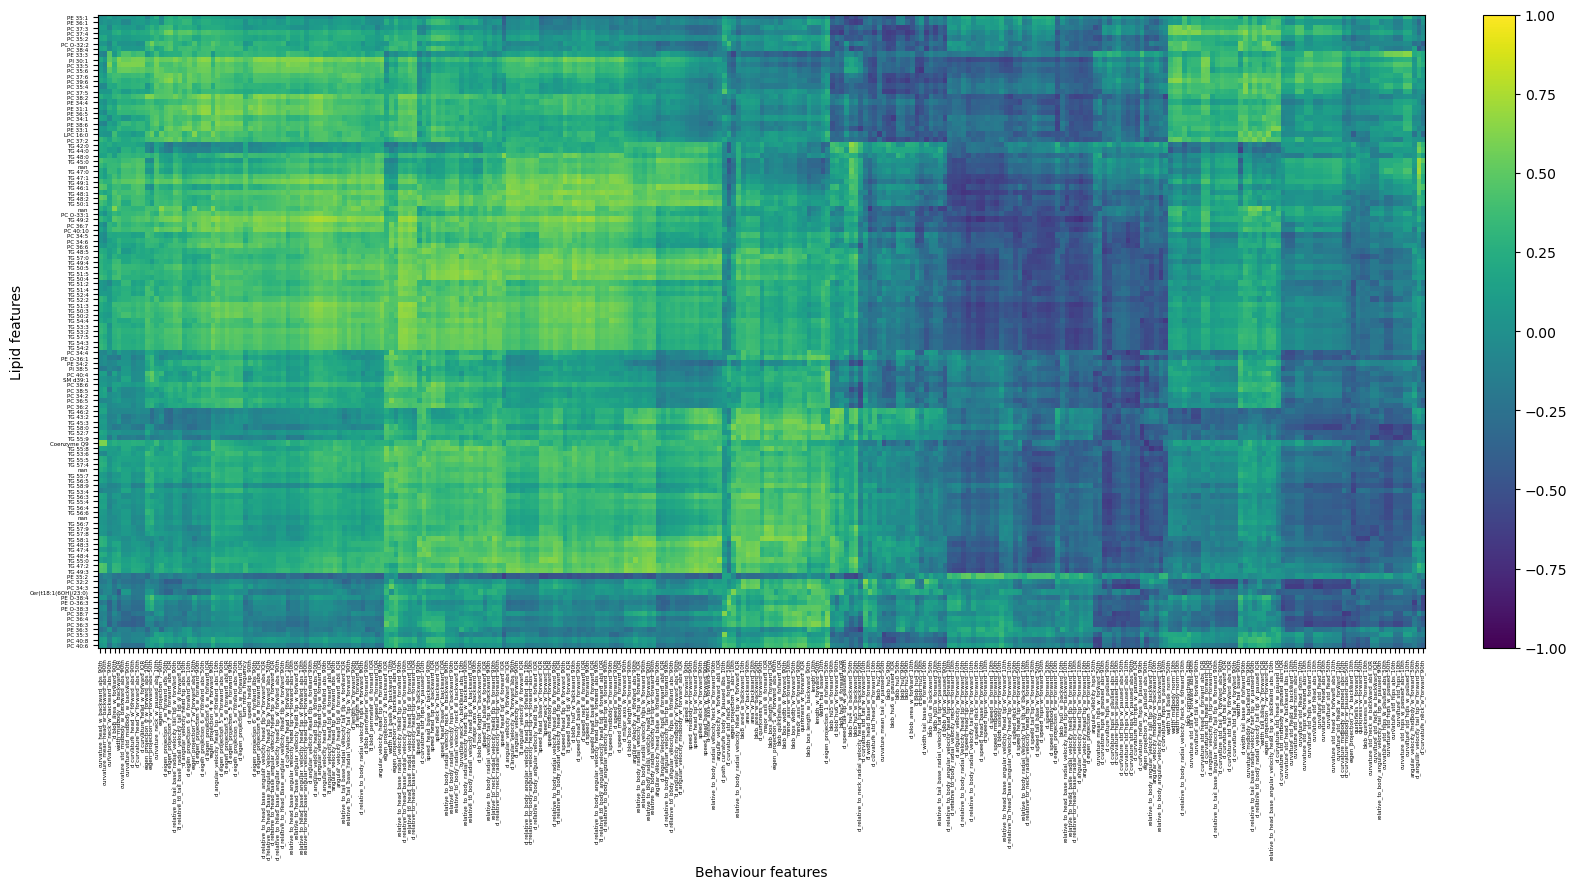

In [24]:
import numpy as np
from scipy.stats import spearmanr, zscore
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

lipid_mask = np.any(np.abs(Wx) > 1e-8, axis=1)
behav_mask = np.any(np.abs(Wy) > 1e-8, axis=1)
lipid_names = data.var["identification"].values
behav_names = data.uns["omics_ethology"].columns[behav_mask].values

X_sel = data.X[:, lipid_mask]
Y_sel = data.uns["omics_ethology"].loc[:, behav_mask].values

X_sel = zscore(X_sel)
Y_sel = zscore(Y_sel)

corr, _ = spearmanr(X_sel, Y_sel)

corr_matrix = corr[:X_sel.shape[1], X_sel.shape[1]:]

threshold = 0.6

lipid_indices = np.where(np.any(np.abs(corr_matrix) > threshold, axis=1))[0]
behav_indices = np.where(np.any(np.abs(corr_matrix) > threshold, axis=0))[0]

X_filtered = X_sel[:, lipid_indices]
Y_filtered = Y_sel[:, behav_indices]
corr_filtered = corr_matrix[np.ix_(lipid_indices, behav_indices)]
filtered_lipid_names = lipid_names[lipid_indices]
filtered_behav_names = behav_names[behav_indices]

row_link = linkage(corr_filtered, method="average")
col_link = linkage(corr_filtered.T, method="average")

row_order = dendrogram(row_link, no_plot=True)['leaves']
col_order = dendrogram(col_link, no_plot=True)['leaves']

corr_clustered = corr_filtered[row_order][:, col_order]

ordered_lipid_names = filtered_lipid_names[row_order]
ordered_behav_names = filtered_behav_names[col_order]

plt.figure(figsize=(16,9))
im = plt.imshow(
    corr_clustered,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.xticks(ticks=np.arange(len(ordered_behav_names)), labels=ordered_behav_names, rotation=90, fontsize=4)
plt.yticks(ticks=np.arange(len(ordered_lipid_names)), labels=ordered_lipid_names, fontsize=4)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xlabel("Behaviour features")
plt.ylabel("Lipid features")
plt.tight_layout()
plt.savefig("/home/zby/scMM/data/ethology_new/lipid_behaviour_correlation.svg", dpi=300)